# Health Analytics (COMS5027A/FAMH4004A) 2026
# Lab 1 - Data Quality Assessment, Data Cleaning & Answering a Health Question

## Instructions
* Run all the code cells in chronological order.
* Put your names and student numbers in the indicated cell in the exact indicated format.
* You cannot use additional libraries to the ones imported already for you.
* Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
* Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
* Do not delete the answer code cells and recreate them as they have custom metadata used by the automarker. If you accidentally delete one, you must redownload the notebook.
* Answers must be computed programmatically. Computing by hand and simply setting the variable to that value will lead to a mark of zero since these will not be valid on the private test cases.

## Imports

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

## Student Details

Populate `student_names` and `student_numbers` with the full names and student numbers of each group member in the same order.

Example:
```
student_names = ["Jane Doe", "John Doe"]
student_numbers = ["123456", "654321"]  # The elements of this list are strings and must be surrounded by quotes!
```

In [ ]:
student_names = ["Odwa Yamile"]  # Provide the FULL name of each group member as it appears on Moodle
student_numbers = ["2593714"]  # Provide the student number of each group member in the same order as student names. Ensure the student numbers are represented as strings

assert len(student_names) == len(student_numbers), "All student names must have an associated student number and vice-versa"
assert np.all([type(x) == str for x in student_numbers]), "All student numbers must be represented as strings"

## Public Test Cases

The 'public test cases' are used for you to check your answers, and sometimes act as a heuristic for if your answer is correct or not. Your answers will be marked by hand and/or programatically using hidden test cases.  

# 1) Data Ingestion

In [4]:
# RUN THIS & DO NOT MODIFY
df = pd.read_csv("https://github.com/SimonRosen173/health-analytics-26-data/blob/main/labs/week%202/covid19za_prov_dirty.csv?raw=true")
df["date"] = pd.to_datetime(df["eowYYYYMMDD"], format="%Y%m%d")  # Create new column of type datetime for date
df.set_index("date", inplace=True)  # Set `date` to be the index
df.drop("eowYYYYMMDD", inplace=True, axis=1)  # Drop (remove) the column 'eowYYYYMMDD' from the dataset
df.head()

,var,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
date,,,,,,,,,,,,
2020-05-09,Positive,759,35,457.0,200.0,10,18,15,6,3745,101,5346
2020-05-09,Tests,13131,5575,40206.0,16263.0,2631,3334,2492,982,22584,979,108177
2020-05-16,Positive,704,90,535.0,320.0,13,61,34,7,5187,220,7171
2020-05-16,Tests,8411,7234,27808.0,16821.0,2922,2889,1969,1019,28041,1752,98866
2020-05-23,Positive,977,102,584.0,325.0,19,62,34,7,6718,222,9050


**Notes on data:**
- This dataset corresponds to a modified version of COVID-19 weekly testing data reported by the NICD and collated by the community and managed by Data Science for Social Impact Research Group at the University of Pretoria.
- This data corresponds to the weekly number of tests conducted per province and the number of tests which were positive for COVID-19. 
- `Unknown` refers to tests or positive tests that were unattributed to a particular province that week.
- `Total` refers to the total accross provinces and `Unknown` for that week.
- N.B. this dataset is in essence two datasets that were merged: a dataset for weekly number of COVID-19 tests, and a dataset for weekly number of positive tests. The column `var` denotes whether a given row corresponds to positive tests (with value `Positive`) or total tests (with value `Tests`). Keeping the datasets in merged form is useful for much of the data quality assessments and EDA, but we will split them when required.
- The dataset is indexed by the end of week date each row corresponds to and is of `DateTime` form. N.B. the index is **not** unique, since it is repeated for `Positive` and `Tests`, e.g. see the first two rows of the above.

### Numerical Only DataFrame
For the simplicity of the data quality assessment we will create a new dataframe called `df_num` that only contains the numerical values (i.e. it drops the column `var`).

Note: For discussion of in-place vs not in-place operations, please see [this guide](https://www.geeksforgeeks.org/python/what-does-inplace-mean-in-pandas/).

In [5]:
df_num = df.drop("var", axis=1)  # `axis=1` refers to columns & by default this will *not* occur in-place - i.e. it will create copy with the dropped column
df_num.head()

,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
date,,,,,,,,,,,
2020-05-09,759,35,457.0,200.0,10,18,15,6,3745,101,5346
2020-05-09,13131,5575,40206.0,16263.0,2631,3334,2492,982,22584,979,108177
2020-05-16,704,90,535.0,320.0,13,61,34,7,5187,220,7171
2020-05-16,8411,7234,27808.0,16821.0,2922,2889,1969,1019,28041,1752,98866
2020-05-23,977,102,584.0,325.0,19,62,34,7,6718,222,9050


# 2) Data Quality Assessment

In this component of the lab you will perform a data quality assessment of the data contained in `df_num`, according to:
1. Completeness
2. Internal consistency
3. External comparisons

But, first we will take a quick look at `df_num` from a high level.

#### Question 1
Show the first 7 rows of `df_num`. 

In [6]:
# STUDENT CODE
df_num.head(7)

,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
date,,,,,,,,,,,
2020-05-09,759,35,457.0,200.0,10,18,15,6,3745,101,5346
2020-05-09,13131,5575,40206.0,16263.0,2631,3334,2492,982,22584,979,108177
2020-05-16,704,90,535.0,320.0,13,61,34,7,5187,220,7171
2020-05-16,8411,7234,27808.0,16821.0,2922,2889,1969,1019,28041,1752,98866
2020-05-23,977,102,584.0,325.0,19,62,34,7,6718,222,9050
2020-05-23,12329,10178,34690.0,18646.0,3036,3135,2059,998,33189,1699,119959
2020-05-30,1550,98,1119.0,796.0,18,92,88,12,7836,121,11730


#### Question 2
Use the `info` method to show the number of non missing values per column and the associated data types of each column in the dataframe `df_num`.

In [7]:
# STUDENT CODE
df_num.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 230 entries, 2020-05-09 to 2022-07-16
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Eastern Cape   230 non-null    int64  
 1   Free State     230 non-null    int64  
 2   Gauteng        228 non-null    float64
 3   KwaZulu-Natal  229 non-null    float64
 4   Limpopo        230 non-null    int64  
 5   Mpumalanga     230 non-null    int64  
 6   North West     230 non-null    int64  
 7   Northern Cape  230 non-null    int64  
 8   Western Cape   230 non-null    int64  
 9   Unknown        230 non-null    int64  
 10  Total          230 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 21.6 KB


Think about: 
- What does this suggest about the completeness of the data?

#### Question 3
Use the `describe` method to show statistical values for the numerical columns in `df_num`.

In [8]:
# STUDENT CODE
df_num.describe()

,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
count,230.000000,230.000000,228.000000,229.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,10212.343478,7007.943478,41319.754386,23100.209607,3470.226087,6194.378261,5467.495652,3172.513043,19088.604348,399.186957,119916.139130
std,10602.363601,6351.910080,43007.114605,23971.834671,4033.113687,6155.194245,5648.414334,3132.674491,17763.527782,992.451332,112265.717248
min,110.000000,35.000000,-33433.000000,200.000000,10.000000,0.000000,15.000000,6.000000,249.000000,0.000000,1819.000000
25%,1106.500000,1435.750000,4950.000000,2242.000000,440.000000,878.250000,859.500000,632.250000,3388.750000,6.250000,19172.000000
50%,8309.500000,5660.000000,30550.000000,17628.000000,2463.000000,4901.000000,3774.000000,2158.000000,16028.500000,49.500000,98356.000000
75%,13469.500000,10658.250000,64913.000000,35078.000000,4827.750000,10030.250000,8321.500000,4730.000000,28674.750000,274.250000,183538.500000
max,54843.000000,27492.000000,223679.000000,126615.000000,22652.000000,32277.000000,27808.000000,14988.000000,72912.000000,8539.000000,482275.000000


Think about: 
- What does this suggest about the consistency of the data? Hint: Look at the min and max values for each relevant column.

### 2.a) Completeness
To measure the completeness of data, you must check for missing data. Missing data may often appear in the form of:
1. NA values
2. Zero values

We have to be careful with zero values however, as sometimes they may be legitimate values that should remain as zeros or sometimes they may have been improperly used to denote missing values.

#### Question 4
Compute the number of `na` values per column in `df_num` and set this to the variable `no_na_srs`. 

Hint: Use the `isna` and `sum` methods.

In [9]:
# STUDENT CODE
no_na_srs = df_num.isna().sum()
no_na_srs

Eastern Cape     0
Free State       0
Gauteng          2
KwaZulu-Natal    1
Limpopo          0
Mpumalanga       0
North West       0
Northern Cape    0
Western Cape     0
Unknown          0
Total            0
dtype: int64

**Public Test Case**

In [10]:
# RUN THIS & DO NOT MODIFY
if int(no_na_srs.sum()) == 3:
    print("Answer for Q4 is likely correct.")
else:
    print("Answer for Q4 is incorrect.")

Answer for Q4 is likely correct.


#### Question 5
Compute the number of 0 values per column in `df_num` and set this to the variable `no_zero_srs`.

Hint: Use a `conditional` to create a dataframe consisting of `True` when the associated value in `df` is equal to `0` and `False` otherwise. Then use `sum` to count the number of `True` values per column.  

In [11]:
# STUDENT CODE
no_zero_srs = (df_num == 0).sum()

no_zero_srs

Eastern Cape      0
Free State        0
Gauteng           0
KwaZulu-Natal     0
Limpopo           0
Mpumalanga        2
North West        0
Northern Cape     0
Western Cape      0
Unknown          14
Total             0
dtype: int64

**Public Test Case**

In [12]:
# RUN THIS & DO NOT MODIFY
if int(no_zero_srs.sum()) == 16:
    print("Answer for Q5 is likely correct.")
else:
    print("Answer for Q5 is incorrect.")

Answer for Q5 is likely correct.


Think About: 
- For which columns does it seem reasonable to have zero values and for which columns is it not reasonable?

### 2.b) Internal Consistency

#### Question 6
Compute the number of values which are less than 0 per column in `df_num` and set this to the variable `no_neg_srs`. 

In [13]:
# STUDENT CODE
no_neg_srs = (df_num < 0).sum()
no_neg_srs

Eastern Cape     0
Free State       0
Gauteng          1
KwaZulu-Natal    0
Limpopo          0
Mpumalanga       0
North West       0
Northern Cape    0
Western Cape     0
Unknown          0
Total            0
dtype: int64

**Public Test Case**

In [14]:
# RUN THIS & DO NOT MODIFY
if int(no_neg_srs.sum()) == 1:
    print("Answer for Q6 is likely correct.")
else:
    print("Answer for Q6 is incorrect.")

Answer for Q6 is likely correct.


#### Question 7
A possible inconsitency in this data is that the number of positive cases reported for a given week may be greater than the reported number of tests performed that week, which would be impossible. Code is provided to split the `df` dataset into seperate datasets corresponding to the positive cases and the total tests, which you will then need to compare.

In [15]:
# RUN THIS & DO NOT MODIFY
df_pos = df[df["var"]=="Positive"]
df_pos.head(3)

,var,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
date,,,,,,,,,,,,
2020-05-09,Positive,759,35,457.0,200.0,10,18,15,6,3745,101,5346
2020-05-16,Positive,704,90,535.0,320.0,13,61,34,7,5187,220,7171
2020-05-23,Positive,977,102,584.0,325.0,19,62,34,7,6718,222,9050


In [16]:
# RUN THIS & DO NOT MODIFY
df_tests = df[df["var"]=="Tests"]
df_tests.head(3)

,var,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape,Unknown,Total
date,,,,,,,,,,,,
2020-05-09,Tests,13131,5575,40206.0,16263.0,2631,3334,2492,982,22584,979,108177
2020-05-16,Tests,8411,7234,27808.0,16821.0,2922,2889,1969,1019,28041,1752,98866
2020-05-23,Tests,12329,10178,34690.0,18646.0,3036,3135,2059,998,33189,1699,119959


For each date (index column) compare if the associated values for positive cases are greater than the associated number of tests. This should be done row-wise and column-wise, e.g. the value of `df_pos` on the `date` of `2020-05-09` for the `Eastern Cape` column should be checked against the corresponding value (cell) in `df_tests` for that index and column. The total number of occurences where a positive cases value is greater than the associated number of tests value must be set to the variable `no_inconsistent_q8`.

Hint: Compare `df_pos` and `df_tests` using a conditional and then apply `sum` twice.

In [17]:
# STUDENT CODE
no_inconsistent_q8 = (df_pos > df_tests).sum().sum()
no_inconsistent_q8

np.int64(3)

**Public Test Case**

In [18]:
# RUN THIS & DO NOT MODIFY
if no_inconsistent_q8 == 3:
    print("Answer for Q8 is likely correct.")
else:
    print("Answer for Q8 is incorrect.")

Answer for Q8 is likely correct.


# 3) Health Question

The data cleaning required and the way we analyse and visualise the data is dictated by the particular health question we wish to answer.

### Question: How does the weekly test positivity rate between the period of 01-11-2020 to 01-03-2021 differ across provinces?

Note: 'test positivity rate' refers to the percentage of COVID-19 tests that were positive, i.e. `(no of tests of positive) / (no of tests)`. 

Note: The time period provided corresponds to the 1st COVID-19 wave in South Africa.  

# 4) Data Cleaning
In order to properly answer this question, we will first need to clean the data according to the issues found in our data quality assessment. For simplicity we will clean all of the data rather than just the data within the range 01-05-2020 to 01-09-2022.

If done correctly the data quality assessment would have found the following issues:
1) Missing province total tests and/or positive tests data.
    -  Represented as NA or as zeros
2) Negative values for no of tests and/or postive tests
3) Occurances when total number of positive tests was greater than the associated total number of tests

These issues only occurred for a small subset of the rows, so for simplicity you will drop the rows that contained the above issues for the provinces columns. This will be done using the `drop` method and conditional indexing.  

**N.B. DO NOT call drop directly on df. Call it on df_clean**

#### Question 8

Remove the rows from `df_clean` that contain negative values or missing values (zero or NA) for provincial data. Follow the steps laid out in the comments below to achieve this.

In [19]:
df_clean = df.copy()  # DO NOT MODIFY THIS LINE

# STUDENT CODE - EDIT ACCORDING TO PROVIDED TODOs
# Use the below list to index columns off - i.e. use the following for the columns you look at
provinces = ['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']

# Step 1: First determine which rows should be dropped.  

# Step 1a)
# Missing values for provinces - NA
# TODO: Set na_cond to be a Series whose values are true when the associated row in df contains provinces with missing values (denoted by NA)
na_cond = df_clean[provinces].isna().any(axis=1)

# Step 1b)
# Missing values for provinces - Zero
# TODO: Set zero_cond to be a Series whose values are true when the associated row in df contains provinces with missing values (denoted by zero)
zero_cond = (df_clean[provinces] == 0).any(axis=1)

# Step 1c)
# Negative values
# TODO: Set neg_cond to be a Series whose values are true when the associated row in df contains provinces with negative values
neg_cond = (df_clean[provinces] < 0).any(axis=1)

# Step 2: Drop the problem rows from df_clean using conditional indexing to find the corresponding indices
# Note: drop requires indices not a Series containing True & False, but we can get those indices directly from the true/false series (conditional)
# by using conditional indexing & then finding the corresponding index. E.g. df[{condition series}].index
drop_index = df_clean[na_cond | zero_cond | neg_cond].index  # replace '...' with correct condition -> Note: For pandas use '|' instead of 'or' for conditionals on a series
df_clean = df_clean.drop(drop_index)
# Or you can replace the above with 3 drop calls with appropriate indices

# ! DO NOT CHANGE ANYTHING BELOW ! #
assert isinstance(na_cond, pd.Series) and na_cond.shape == (230, ), "na_cond is incorrect. It should be a Series (column) that is of the same length as the number of rows of df"
assert isinstance(zero_cond, pd.Series)  and zero_cond.shape == (230, ), "zero_cond is incorrect. It should be a Series (column) that is of the same length as the number of rows of df"
assert isinstance(neg_cond, pd.Series)  and neg_cond.shape == (230, ), "neg_cond is incorrect. It should be a Series (column) that is of the same length as the number of rows of df"

if na_cond.sum() == 3:
    print("na_cond likely has correct value")
else:
    print("na_cond has incorrect value")

if zero_cond.sum() == 2:
    print("zero_cond likely has correct value")
else:
    print("zero_cond has incorrect value")

if neg_cond.sum() == 1:
    print("neg_cond likely has correct value")
else:
    print("neg_cond has incorrect value")

na_cond likely has correct value
zero_cond likely has correct value
neg_cond likely has correct value


#### Question 9
Remove the rows from `df_clean_pos` and `df_clean_tests` that correspond to dates where the number of positives tests for a particular province exceeded the total number of tests for that province.

In [20]:
# STUDENT CODE
df_clean_pos = df_clean[df_clean["var"] == "Positive"].copy()  # DO NOT MODIFY THIS LINE
df_clean_tests = df_clean[df_clean["var"] == "Tests"].copy()  # DO NOT MODIFY THIS LINE

provinces = ['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']

# TODO ...
inconsistent_cond = (df_clean_pos[provinces] > df_clean_tests[provinces]).any(axis=1)
drop_index = df_clean_pos[inconsistent_cond].index
df_clean_pos = df_clean_pos.drop(drop_index)
df_clean_tests = df_clean_tests.drop(drop_index)

# DO NOT MODIFY BELOW
if df_clean_pos.shape == df_clean_tests.shape == (107, 12):
    print("Q9 might be correct")
else:
    print("Q9 is not correct")

Q9 might be correct


# 5) Answering the Health Question

#### Question 10

Compute a new dataframe df_pos_rate whose index corresponds to the index (dates) of `df_clean_pos` and `df_clean_test`, and whose columns are the provinces. The value for a particular date and province is computed as the number of associated positive cases divided by the total number of associated tests.

In [21]:
# STUDENT ANSWER
df_pos_rate = df_clean_pos[provinces] / df_clean_tests[provinces]
df_pos_rate

,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape
date,,,,,,,,,
2020-05-09,0.057802,0.006278,0.011366,0.012298,0.003801,0.005399,0.006019,0.006110,0.165825
2020-05-16,0.083700,0.012441,0.019239,0.019024,0.004449,0.021115,0.017268,0.006869,0.184979
2020-05-23,0.079244,0.010022,0.016835,0.017430,0.006258,0.019777,0.016513,0.007014,0.202416
2020-05-30,0.108369,0.012535,0.029809,0.041482,0.005939,0.027259,0.036928,0.011516,0.231437
2020-06-06,0.152343,0.011257,0.052044,0.031598,0.011442,0.043938,0.071616,0.021339,0.245307
...,...,...,...,...,...,...,...,...,...
2022-06-18,0.067506,0.065439,0.063011,0.040506,0.070299,0.057376,0.078322,0.085106,0.101054
2022-06-25,0.042220,0.038336,0.049346,0.030038,0.053290,0.059987,0.060337,0.046137,0.076739
2022-07-02,0.065647,0.035957,0.044746,0.029673,0.048346,0.051514,0.047192,0.046436,0.056533


#### Question 11

Using `df_pos_rate` create a line plot showing the test positivity rate on the y-axis plotted against the date on the x-axis for each province for the time period 01-11-2020 to 01-03-2021. N.B. it must be a single graph with a seperate line for each province. This graph should include appropriate x and y labels and an appropriate legend/key.

Hint: 
- This is easier to do with Seaborn (see [seaborn.lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html)) than just using Matplotlib.
- You can index using `loc` with DateTime objects if you wish to retrieve a certain range.

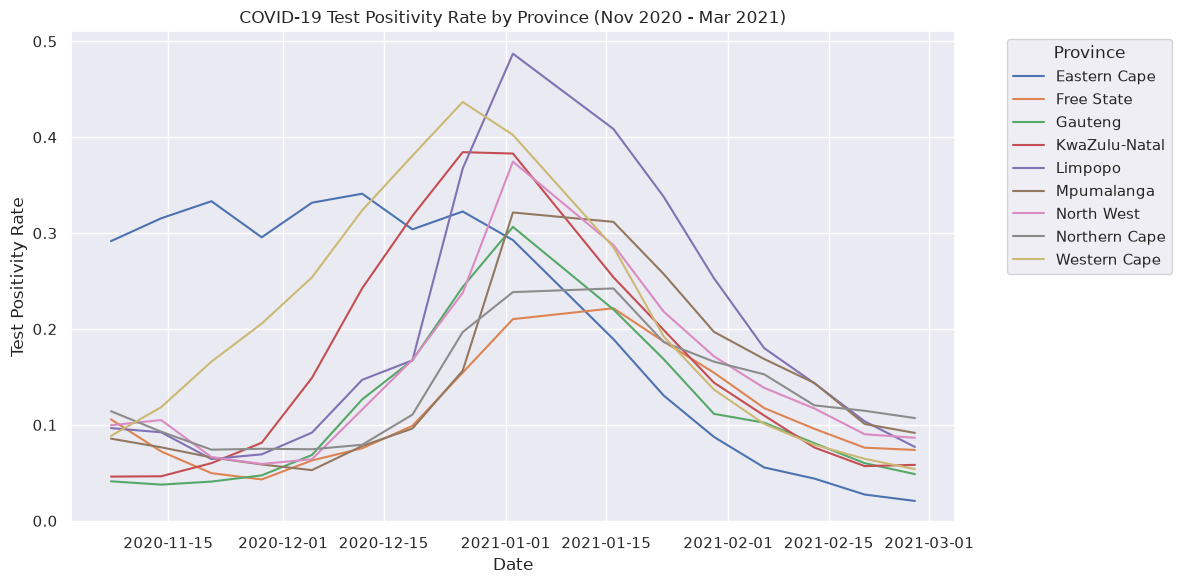

In [22]:
# STUDENT ANSWER
# TODO
# STUDENT ANSWER
df_pos_rate_range = df_pos_rate.loc["2020-11-01":"2021-03-01"]
df_long = df_pos_rate_range.reset_index().melt(id_vars="date", var_name="province", value_name="positivity_rate")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_long, x="date", y="positivity_rate", hue="province")
plt.xlabel("Date")
plt.ylabel("Test Positivity Rate")
plt.title("COVID-19 Test Positivity Rate by Province (Nov 2020 - Mar 2021)")
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Question 11

Given the plot created for Question 10, provide a short (2-3 sentence) answer to the provided health question. Answer in the Markdown cell below.

YOUR ANSWER GOES HERE - Double click this cell.

## MY ANSWER
All provinces show a similar rise in test positivity rate from November 2020, peaking around late December 2020 to early January 2021, before declining through February 2021 — reflecting South Africa's first COVID-19 wave. However, the timing and magnitude of the peak varied by province: Limpopo and Western Cape reached the highest peak positivity rates (around 0.45–0.49), while Eastern Cape's rate rose earlier and more gradually, and provinces like Free State and Gauteng had comparatively lower peaks (around 0.2–0.3).


# END